In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
# Basic
import os
import cv2
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Image processing
from PIL import Image
from skimage.feature import hog

# Deep Learning
import tensorflow as tf

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg_preprocess

# Machine Learning
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# Metrics
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)

# Cross Validation
from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_predict
)


2026-06-22 06:11:11.638649: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782108671.870506      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782108671.931526      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782108672.491094      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782108672.491147      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782108672.491150      24 computation_placer.cc:177] computation placer alr

In [3]:
import os
import cv2
import numpy as np

ck_data = []
ck_labels = []

ck_path = "/kaggle/input/datasets/shawon10/ckplus/CK+48"

emotion_names = sorted(os.listdir(ck_path))

for label, emotion in enumerate(emotion_names):

    emotion_path = os.path.join(ck_path, emotion)

    for img_name in os.listdir(emotion_path):

        img_path = os.path.join(emotion_path, img_name)

        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

        if img is None:
            continue

        img = cv2.resize(img, (128,128))

        ck_data.append(img)
        ck_labels.append(label)

ck_data = np.array(ck_data)
ck_labels = np.array(ck_labels)

print("CK+ Shape:", ck_data.shape)
print("Labels:", np.unique(ck_labels))
print("Classes:", emotion_names)

CK+ Shape: (981, 128, 128)
Labels: [0 1 2 3 4 5 6]
Classes: ['anger', 'contempt', 'disgust', 'fear', 'happy', 'sadness', 'surprise']


In [4]:
print("Total Images :", len(ck_data))
print("Total Classes:", len(emotion_names))

for i, emotion in enumerate(emotion_names):
    print(f"{emotion} : {(ck_labels==i).sum()}")

Total Images : 981
Total Classes: 7
anger : 135
contempt : 54
disgust : 177
fear : 75
happy : 207
sadness : 84
surprise : 249


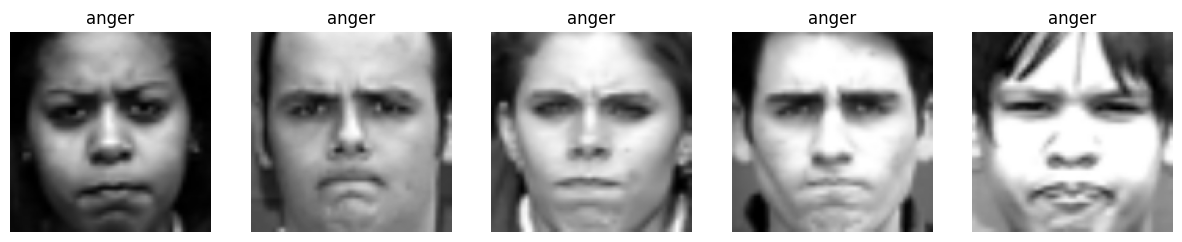

In [5]:
plt.figure(figsize=(15,5))

for i in range(5):

    plt.subplot(1,5,i+1)

    plt.imshow(ck_data[i], cmap='gray')

    plt.title(emotion_names[ck_labels[i]])

    plt.axis('off')

plt.show()

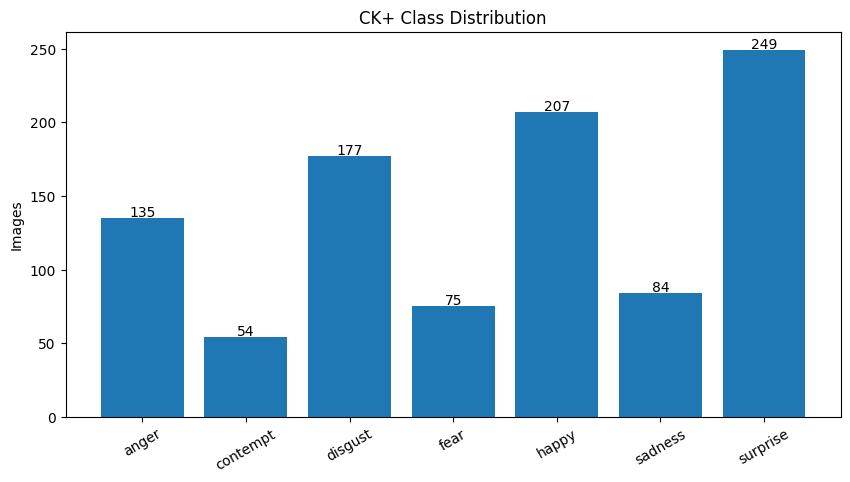

In [6]:
class_counts = []

for i in range(len(emotion_names)):
    class_counts.append((ck_labels==i).sum())

plt.figure(figsize=(10,5))

bars = plt.bar(emotion_names, class_counts)

plt.title("CK+ Class Distribution")
plt.ylabel("Images")

for bar in bars:

    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height()+1,
        str(int(bar.get_height())),
        ha='center'
    )

plt.xticks(rotation=30)

plt.show()

In [7]:
X_hog = []

for img in ck_data:

    feature = hog(
        img,
        orientations=9,
        pixels_per_cell=(8,8),
        cells_per_block=(2,2)
    )

    X_hog.append(feature)

X_hog = np.array(X_hog)

print("HOG Shape:", X_hog.shape)

HOG Shape: (981, 8100)


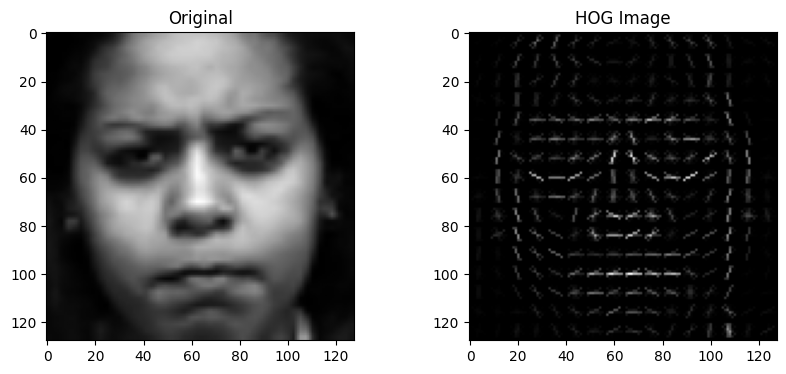

In [8]:
sample = ck_data[0]

features, hog_image = hog(
    sample,
    orientations=9,
    pixels_per_cell=(8,8),
    cells_per_block=(2,2),
    visualize=True
)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(sample, cmap='gray')
plt.title("Original")

plt.subplot(1,2,2)
plt.imshow(hog_image, cmap='gray')
plt.title("HOG Image")

plt.show()

In [9]:
mobilenet = MobileNetV2(
    weights='imagenet',
    include_top=False,
    pooling='avg'
)

vgg = VGG16(
    weights='imagenet',
    include_top=False,
    pooling='avg'
)

print("Models Loaded")

/tmp/ipykernel_24/3425155617.py:1: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  mobilenet = MobileNetV2(
I0000 00:00:1782108696.566327      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1782108696.572290      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Models Loaded


In [10]:
def extract_mobilenet_features(images, model):

    features = []

    for img in images:

        img = cv2.resize(img, (224,224))

        img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)

        img = preprocess_input(img)

        img = np.expand_dims(img, axis=0)

        feat = model.predict(img, verbose=0)

        features.append(feat.flatten())

    return np.array(features)

In [11]:
def extract_vgg_features(images, model):

    features = []

    for img in images:

        img = cv2.resize(img, (224,224))

        img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)

        img = vgg_preprocess(img)

        img = np.expand_dims(img, axis=0)

        feat = model.predict(img, verbose=0)

        features.append(feat.flatten())

    return np.array(features)

In [12]:
X_cnn = extract_mobilenet_features(
    ck_data,
    mobilenet
)

print("MobileNet Shape:", X_cnn.shape)

X_vgg = extract_vgg_features(
    ck_data,
    vgg
)

print("VGG Shape:", X_vgg.shape)

I0000 00:00:1782108704.212849      72 service.cc:152] XLA service 0x7c538800e1d0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1782108704.212904      72 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1782108704.212908      72 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1782108704.845258      72 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-06-22 06:11:53.193056: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-22 06:11:53.349344: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-22 06:11:53.483343: E external/local_xl

MobileNet Shape: (981, 1280)
VGG Shape: (981, 512)


In [13]:
# VGG + MobileNet

X_hybrid = np.concatenate(
    [X_cnn, X_vgg],
    axis=1
)

# HOG + MobileNet

X_hog_cnn = np.concatenate(
    [X_hog, X_cnn],
    axis=1
)

# HOG + VGG

X_hog_vgg = np.concatenate(
    [X_hog, X_vgg],
    axis=1
)

# HOG + VGG + MobileNet

X_final = np.concatenate(
    [X_hog, X_cnn, X_vgg],
    axis=1
)

print("Hybrid Shape:", X_hybrid.shape)
print("Final Shape :", X_final.shape)

Hybrid Shape: (981, 1792)
Final Shape : (981, 9892)


In [14]:
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_predict

emotion_names = emotion_names

def run_model_cv(X, name):

    model = Pipeline([
        ('scaler', StandardScaler()),
        ('svm', SVC(kernel='linear'))
    ])

    skf = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    y_pred = cross_val_predict(
        model,
        X,
        ck_labels,
        cv=skf
    )

    acc = accuracy_score(
        ck_labels,
        y_pred
    )

    print(f"\n{name} Accuracy: {acc:.4f}")

    report = classification_report(
        ck_labels,
        y_pred,
        target_names=emotion_names,
        output_dict=True
    )

    cm = confusion_matrix(
        ck_labels,
        y_pred
    )

    return {
        'name': name,
        'accuracy': acc,
        'report': report,
        'cm': cm,
        'y_pred': y_pred
    }

In [15]:
results = []

results.append(
    run_model_cv(X_hog, "HOG")
)

results.append(
    run_model_cv(X_cnn, "MobileNet")
)

results.append(
    run_model_cv(X_vgg, "VGG16")
)

results.append(
    run_model_cv(
        X_hybrid,
        "VGG + MobileNet"
    )
)

results.append(
    run_model_cv(
        X_hog_vgg,
        "HOG + VGG"
    )
)

results.append(
    run_model_cv(
        X_hog_cnn,
        "HOG + MobileNet"
    )
)

results.append(
    run_model_cv(
        X_final,
        "All Features"
    )
)


HOG Accuracy: 1.0000

MobileNet Accuracy: 0.9888

VGG16 Accuracy: 0.9908

VGG + MobileNet Accuracy: 0.9918

HOG + VGG Accuracy: 1.0000

HOG + MobileNet Accuracy: 1.0000

All Features Accuracy: 1.0000


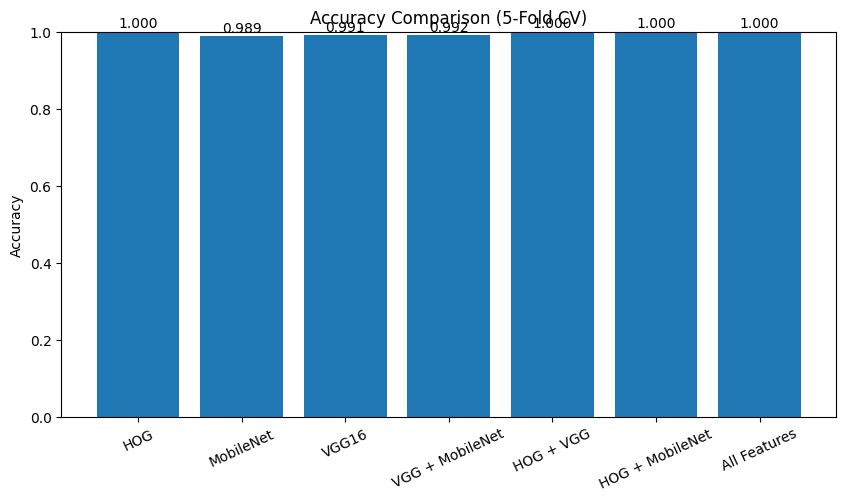

In [16]:
model_names = []
accuracies = []

for res in results:

    model_names.append(
        res['name']
    )

    accuracies.append(
        res['accuracy']
    )

plt.figure(figsize=(10,5))

bars = plt.bar(
    model_names,
    accuracies
)

plt.ylim(0,1)

plt.title(
    "Accuracy Comparison (5-Fold CV)"
)

plt.ylabel("Accuracy")

for bar in bars:

    yval = bar.get_height()

    plt.text(
        bar.get_x() +
        bar.get_width()/2,
        yval + 0.01,
        f"{yval:.3f}",
        ha='center'
    )

plt.xticks(rotation=25)

plt.show()

In [17]:
accuracy_df = pd.DataFrame({
    'Model': model_names,
    'Accuracy': accuracies
})

accuracy_df.sort_values(
    by='Accuracy',
    ascending=False,
    inplace=True
)

accuracy_df

,Model,Accuracy
0,HOG,1.000000
5,HOG + MobileNet,1.000000
4,HOG + VGG,1.000000
6,All Features,1.000000
3,VGG + MobileNet,0.991845
2,VGG16,0.990826
1,MobileNet,0.988787


In [18]:
emotion_f1 = pd.DataFrame()

for res in results:

    model_name = res['name']

    scores = []

    for emotion in emotion_names:

        scores.append(
            res['report'][emotion]['f1-score']
        )

    emotion_f1[model_name] = scores

emotion_f1.index = emotion_names

emotion_f1

,HOG,MobileNet,VGG16,VGG + MobileNet,HOG + VGG,HOG + MobileNet,All Features
anger,1.0,0.967273,0.978261,0.978102,1.0,1.0,1.0
contempt,1.0,1.000000,1.000000,1.000000,1.0,1.0,1.0
disgust,1.0,0.991453,0.980057,0.994318,1.0,1.0,1.0
fear,1.0,1.000000,1.000000,1.000000,1.0,1.0,1.0
happy,1.0,1.000000,0.997579,1.000000,1.0,1.0,1.0
sadness,1.0,0.952381,0.988095,0.964286,1.0,1.0,1.0
surprise,1.0,0.995968,0.995968,0.995968,1.0,1.0,1.0


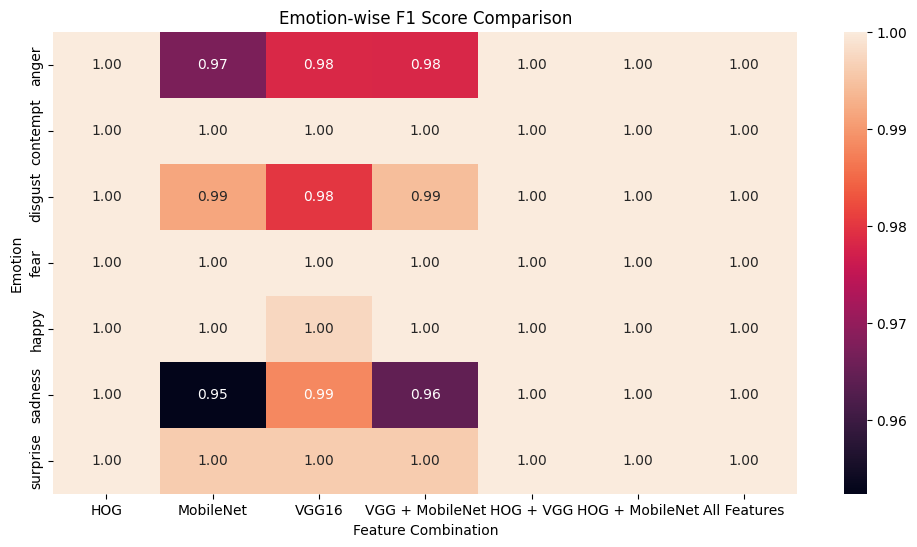

In [19]:
plt.figure(figsize=(12,6))

sns.heatmap(
    emotion_f1,
    annot=True,
    fmt='.2f'
)

plt.title(
    "Emotion-wise F1 Score Comparison"
)

plt.xlabel(
    "Feature Combination"
)

plt.ylabel(
    "Emotion"
)

plt.show()

In [20]:
best_models = {}

for emotion in emotion_names:

    best_model = (
        emotion_f1.loc[emotion]
        .idxmax()
    )

    best_score = (
        emotion_f1.loc[emotion]
        .max()
    )

    best_models[emotion] = (
        best_model,
        best_score
    )

print(
    "\n=== BEST FEATURE SET FOR EACH EMOTION ===\n"
)

for emotion, (model, score) in best_models.items():

    print(
        f"{emotion}: "
        f"{model} "
        f"({score:.3f})"
    )


=== BEST FEATURE SET FOR EACH EMOTION ===

anger: HOG (1.000)
contempt: HOG (1.000)
disgust: HOG (1.000)
fear: HOG (1.000)
happy: HOG (1.000)
sadness: HOG (1.000)
surprise: HOG (1.000)


In [21]:
expert_df = pd.DataFrame(
    columns=[
        'Emotion',
        'Best Expert',
        'F1 Score'
    ]
)

for emotion in emotion_names:

    best_model = (
        emotion_f1.loc[emotion]
        .idxmax()
    )

    best_score = (
        emotion_f1.loc[emotion]
        .max()
    )

    expert_df.loc[
        len(expert_df)
    ] = [
        emotion,
        best_model,
        round(best_score,3)
    ]

expert_df

,Emotion,Best Expert,F1 Score
0,anger,HOG,1.0
1,contempt,HOG,1.0
2,disgust,HOG,1.0
3,fear,HOG,1.0
4,happy,HOG,1.0
5,sadness,HOG,1.0
6,surprise,HOG,1.0


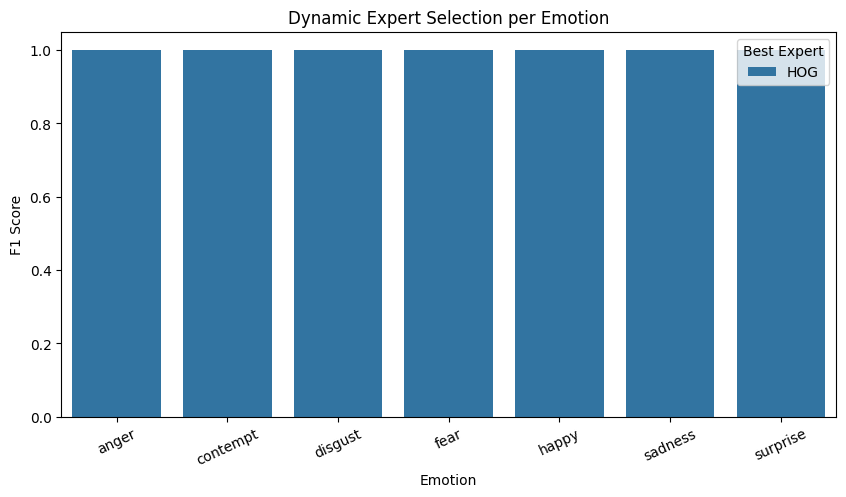

In [22]:
plt.figure(figsize=(10,5))

sns.barplot(
    x='Emotion',
    y='F1 Score',
    hue='Best Expert',
    data=expert_df
)

plt.title(
    "Dynamic Expert Selection per Emotion"
)

plt.xticks(rotation=25)

plt.show()

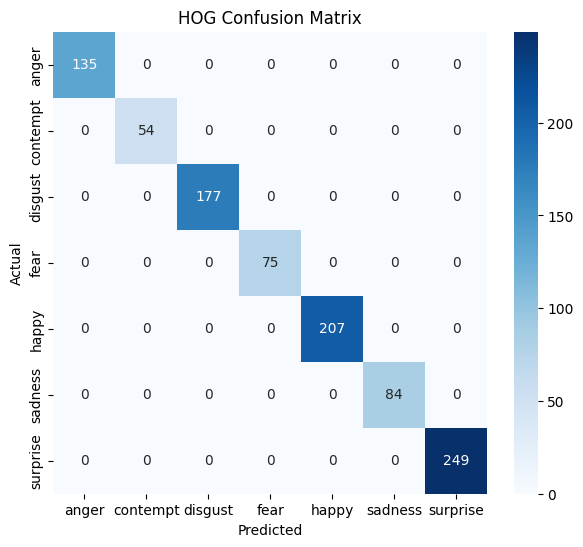

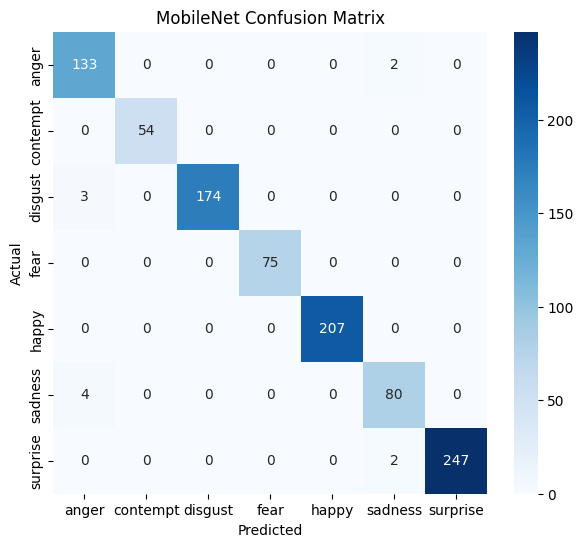

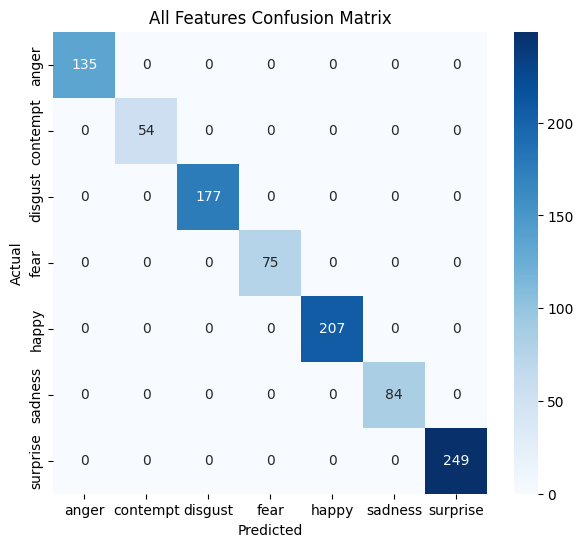

In [23]:
important_models = [
    "HOG",
    "MobileNet",
    "All Features"
]

for res in results:

    if res['name'] in important_models:

        plt.figure(figsize=(7,6))

        sns.heatmap(
            res['cm'],
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=emotion_names,
            yticklabels=emotion_names
        )

        plt.title(
            f"{res['name']} Confusion Matrix"
        )

        plt.xlabel("Predicted")

        plt.ylabel("Actual")

        plt.show()

In [24]:
summary = []

for res in results:

    summary.append([
        res['name'],
        round(res['accuracy'],4),
        round(
            res['report']['macro avg']['precision'],
            4
        ),
        round(
            res['report']['macro avg']['recall'],
            4
        ),
        round(
            res['report']['macro avg']['f1-score'],
            4
        )
    ])

summary_df = pd.DataFrame(
    summary,
    columns=[
        'Model',
        'Accuracy',
        'Precision',
        'Recall',
        'F1 Score'
    ]
)

summary_df.sort_values(
    by='Accuracy',
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score
0,HOG,1.0000,1.0000,1.0000,1.0000
5,HOG + MobileNet,1.0000,1.0000,1.0000,1.0000
4,HOG + VGG,1.0000,1.0000,1.0000,1.0000
6,All Features,1.0000,1.0000,1.0000,1.0000
3,VGG + MobileNet,0.9918,0.9898,0.9911,0.9904
2,VGG16,0.9908,0.9906,0.9924,0.9914
1,MobileNet,0.9888,0.9861,0.9875,0.9867


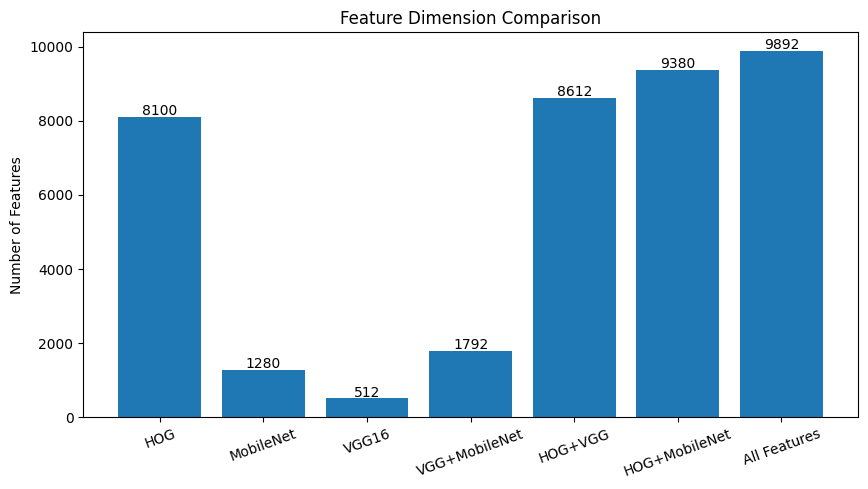

In [25]:
feature_dims = {
    "HOG": X_hog.shape[1],
    "MobileNet": X_cnn.shape[1],
    "VGG16": X_vgg.shape[1],
    "VGG+MobileNet": X_hybrid.shape[1],
    "HOG+VGG": X_hog_vgg.shape[1],
    "HOG+MobileNet": X_hog_cnn.shape[1],
    "All Features": X_final.shape[1]
}

plt.figure(figsize=(10,5))

bars = plt.bar(
    feature_dims.keys(),
    feature_dims.values()
)

plt.title("Feature Dimension Comparison")
plt.ylabel("Number of Features")

for bar in bars:

    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height()+50,
        str(int(bar.get_height())),
        ha='center'
    )

plt.xticks(rotation=20)

plt.show()

In [26]:
metrics_df = []

for res in results:

    metrics_df.append([
        res['name'],
        res['report']['macro avg']['precision'],
        res['report']['macro avg']['recall'],
        res['report']['macro avg']['f1-score']
    ])

metrics_df = pd.DataFrame(
    metrics_df,
    columns=[
        'Model',
        'Precision',
        'Recall',
        'F1'
    ]
)

metrics_df

,Model,Precision,Recall,F1
0,HOG,1.000000,1.000000,1.000000
1,MobileNet,0.986054,0.987512,0.986725
2,VGG16,0.990578,0.992426,0.991423
3,VGG + MobileNet,0.989759,0.991078,0.990382
4,HOG + VGG,1.000000,1.000000,1.000000
5,HOG + MobileNet,1.000000,1.000000,1.000000
6,All Features,1.000000,1.000000,1.000000


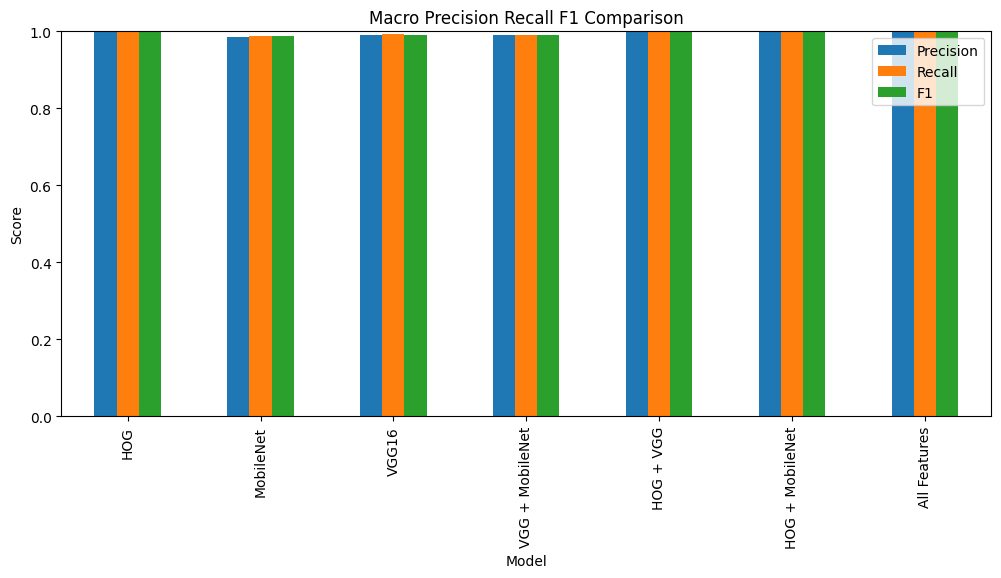

In [27]:
metrics_df.set_index('Model').plot(
    kind='bar',
    figsize=(12,5)
)

plt.title(
    "Macro Precision Recall F1 Comparison"
)

plt.ylabel("Score")

plt.ylim(0,1)

plt.show()

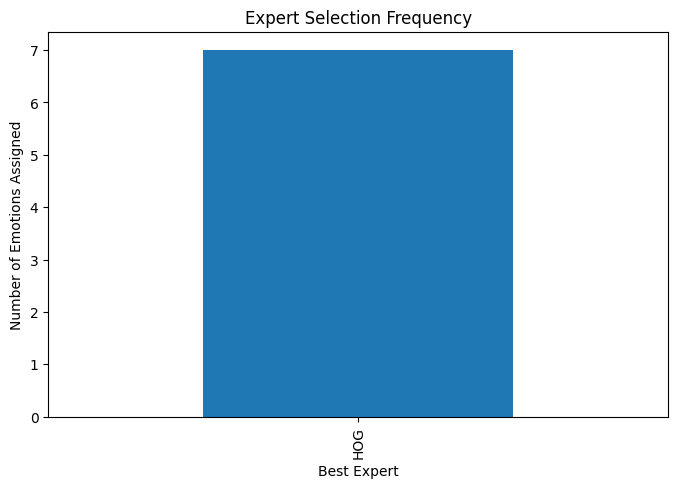

Best Expert
HOG    7
Name: count, dtype: int64


In [28]:
expert_counts = (
    expert_df['Best Expert']
    .value_counts()
)

plt.figure(figsize=(8,5))

expert_counts.plot(
    kind='bar'
)

plt.title(
    "Expert Selection Frequency"
)

plt.ylabel(
    "Number of Emotions Assigned"
)

plt.show()

print(expert_counts)

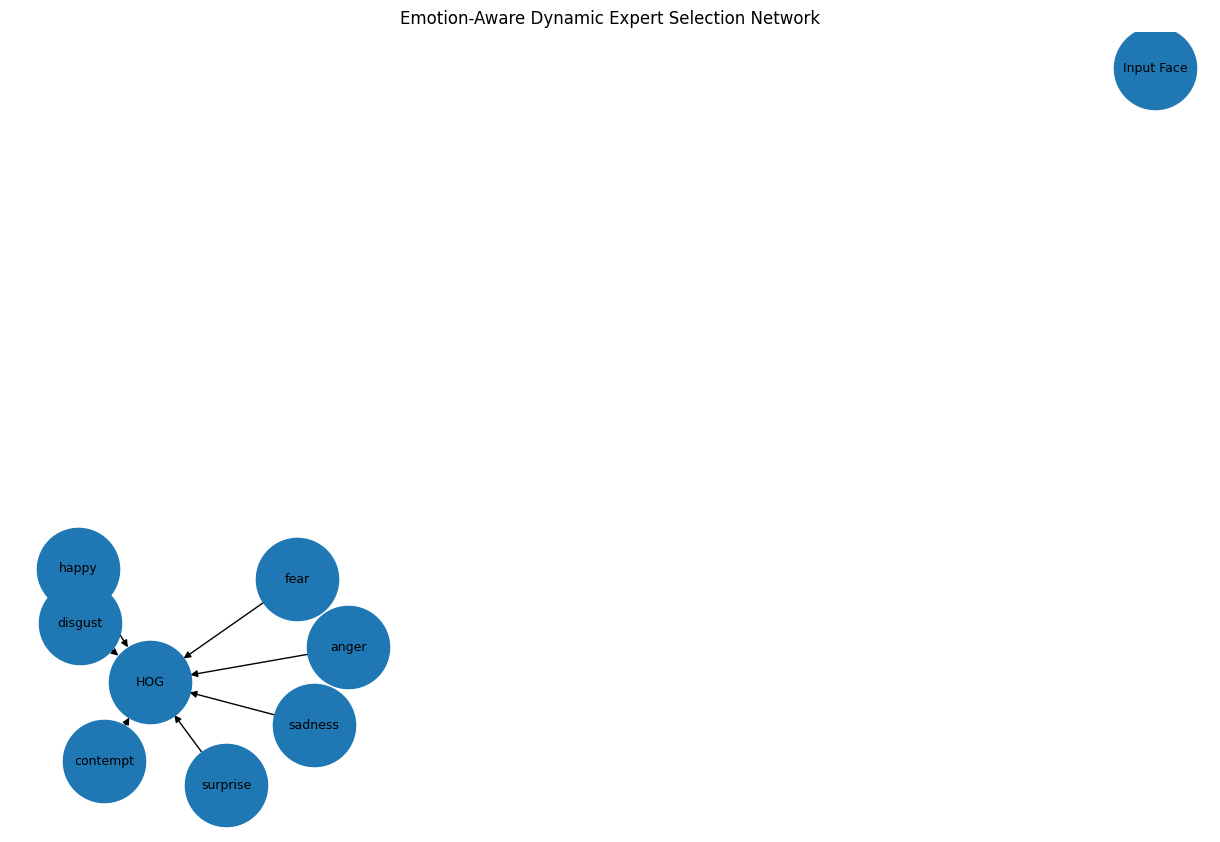

In [29]:
import networkx as nx

G = nx.DiGraph()

G.add_node("Input Face")

for emotion in emotion_names:

    G.add_node(emotion)

for expert in expert_df['Best Expert'].unique():

    G.add_node(expert)

for _, row in expert_df.iterrows():

    G.add_edge(
        row['Emotion'],
        row['Best Expert']
    )

plt.figure(figsize=(12,8))

pos = nx.spring_layout(
    G,
    seed=42
)

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=3500,
    font_size=9
)

plt.title(
    "Emotion-Aware Dynamic Expert Selection Network"
)

plt.show()

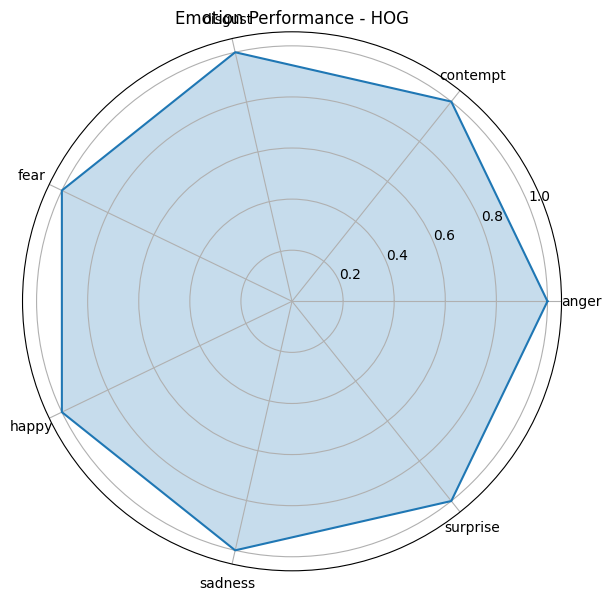

In [30]:
import numpy as np

best_model = accuracy_df.iloc[0]['Model']

best_result = None

for res in results:

    if res['name'] == best_model:

        best_result = res
        break

scores = []

for emotion in emotion_names:

    scores.append(
        best_result['report'][emotion]['f1-score']
    )

scores += scores[:1]

angles = np.linspace(
    0,
    2*np.pi,
    len(emotion_names),
    endpoint=False
).tolist()

angles += angles[:1]

fig = plt.figure(figsize=(7,7))

ax = plt.subplot(
    111,
    polar=True
)

ax.plot(
    angles,
    scores
)

ax.fill(
    angles,
    scores,
    alpha=0.25
)

ax.set_xticks(
    angles[:-1]
)

ax.set_xticklabels(
    emotion_names
)

plt.title(
    f"Emotion Performance - {best_model}"
)

plt.show()

In [31]:
summary_df.to_csv(
    "CKPLUS_Performance_Summary.csv",
    index=False
)

emotion_f1.to_csv(
    "CKPLUS_EmotionWise_F1.csv"
)

expert_df.to_csv(
    "CKPLUS_Dynamic_Experts.csv",
    index=False
)

print("Files Saved")

Files Saved


In [32]:
expert_df.sort_values(
    by='F1 Score',
    ascending=False
)

,Emotion,Best Expert,F1 Score
0,anger,HOG,1.0
1,contempt,HOG,1.0
2,disgust,HOG,1.0
3,fear,HOG,1.0
4,happy,HOG,1.0
5,sadness,HOG,1.0
6,surprise,HOG,1.0


In [33]:
np.save("X_hog.npy", X_hog)
np.save("X_cnn.npy", X_cnn)
np.save("X_vgg.npy", X_vgg)
np.save("X_hybrid.npy", X_hybrid)
np.save("X_hog_cnn.npy", X_hog_cnn)
np.save("X_hog_vgg.npy", X_hog_vgg)
np.save("X_final.npy", X_final)

np.save("labels.npy", ck_labels)

print("Saved Successfully")

Saved Successfully


In [34]:
X_hog = np.load("X_hog.npy")
X_cnn = np.load("X_cnn.npy")
X_vgg = np.load("X_vgg.npy")
X_hybrid = np.load("X_hybrid.npy")
X_hog_cnn = np.load("X_hog_cnn.npy")
X_hog_vgg = np.load("X_hog_vgg.npy")
X_final = np.load("X_final.npy")

ck_labels = np.load("labels.npy")

In [35]:
summary_df.to_csv(
    "CKPLUS_Performance_Summary.csv",
    index=False
)

emotion_f1.to_csv(
    "CKPLUS_EmotionWise_F1.csv"
)

expert_df.to_csv(
    "CKPLUS_Dynamic_Experts.csv",
    index=False
)

In [36]:
# Save features
np.save("X_final.npy", X_final)

# Save tables
summary_df.to_csv("summary.csv", index=False)

# Save notebook version manually